# B6 (Partie 2) — Auto-encodeur & Détection d'Anomalies

**Prérequis** : TP1 exécuté — `norm_stats.json` présent dans `DL/`.

> L'auto-encodeur apprend à reconstruire **uniquement des pièces saines**. Tout ce qu'il reconstruit mal devient suspect.

Lancer depuis `DL/` : `cd DL && jupyter notebook`

## §0 — Setup

In [1]:
import os, sys
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"   # masque les messages info TF
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("src")))

from indusense.vision.dataset  import load_train_val, load_test, load_masks
from indusense.vision.augment  import build_pipeline
from indusense.vision.model    import build_autoencoder, compression_ratio, ssim_loss, mse_ssim_loss
from indusense.vision.train    import train as ae_train
from indusense.vision.anomaly  import (
    reconstruction_errors, calibrate_threshold,
    pixel_error_map, plot_heatmap,
    plot_score_histogram, evaluate, plot_confusion_matrix,
)

BOTTLE_ROOT = Path("bottle")
SEED        = 42
Path("figures").mkdir(exist_ok=True)
Path("checkpoints").mkdir(exist_ok=True)

# Chargement en [0, 1] — PAS de standardisation :
# la sortie sigmoid du décodeur est dans [0, 1], la cible doit l'être aussi.
X_train, X_val = load_train_val(BOTTLE_ROOT, val_ratio=0.2, seed=SEED)
X_test, y_test, test_classes = load_test(BOTTLE_ROOT)
masks = load_masks(BOTTLE_ROOT)

defect_classes = sorted(set(c for c in test_classes if c != "good"))
print(f"Train : {X_train.shape}  Val : {X_val.shape}  Test : {X_test.shape}")
print(f"Plage : [{X_train.min():.3f}, {X_train.max():.3f}]  (attendu [0, 1])")

Train : (168, 256, 256, 3)  Val : (41, 256, 256, 3)  Test : (83, 256, 256, 3)
Plage : [0.098, 1.000]  (attendu [0, 1])


## §1 — Architecture de l'auto-encodeur

3 couches Conv2D (stride=2, relu) → 3 couches Conv2DTranspose (stride=2) → sigmoid.

**Point clé : ratio de compression.**  
Si le ratio est proche de 1, le modèle peut apprendre une quasi-identité et reconstruire *aussi* les défauts → signal d'anomalie nul.

In [2]:
model = build_autoencoder(input_shape=(256, 256, 3), filters=(32, 64, 128))
model.summary()

ratio = compression_ratio(model)
print(f"\nRatio de compression : {ratio:.2f}")
if ratio < 3:
    print("⚠ Ratio < 3 — risque d'apprentissage d'une quasi-identité !")
    print("   → Le modèle pourrait reconstruire les défauts aussi fidèlement que les pièces saines.")
else:
    print("✓ Ratio suffisant pour forcer une représentation compacte.")

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc1 (Conv2D)                   │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc2 (Conv2D)                   │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc3 (Conv2D)                   │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec1 (Conv2DTranspose)          │ (None, 64, 64, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec2 (Conv2DTranspose)          │ (None, 128, 128, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec3 (Conv2DTranspose)          │ (None, 256, 256, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 186,371 (728.01 KB)

 Trainable params: 186,371 (728.01 KB)

 Non-trainable params: 0 (0.00 B)


Ratio de compression : 1.50
⚠ Ratio < 3 — risque d'apprentissage d'une quasi-identité !
   → Le modèle pourrait reconstruire les défauts aussi fidèlement que les pièces saines.


## §2 — Entraînement

- **Cible = entrée** (reconstruction non supervisée).
- Perte : `MSE` par défaut, essayez `mse_ssim_loss()` pour la texture.
- Suivi dans **MLflow** : `mlflow ui` depuis `DL/` pour visualiser.

In [3]:
pipeline = build_pipeline()   # augmentation pendant l'entraînement

history = ae_train(
    model,
    X_train, X_val,
    pipeline=pipeline,
    epochs=50,
    batch_size=16,
    learning_rate=1e-3,
    loss="mse",               # essayez : mse_ssim_loss(alpha=0.8)
    run_name="ae-bottle-mse",
    checkpoint_path="checkpoints/ae_best.keras",
)

2026/07/21 13:50:24 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/21 13:50:24 INFO mlflow.store.db.utils: Updating database tables


Epoch 1/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 193ms/step - loss: 0.1130 - val_loss: 0.0862 - learning_rate: 0.0010
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 192ms/step - loss: 0.0668 - val_loss: 0.0383 - learning_rate: 0.0010
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 192ms/step - loss: 0.0411 - val_loss: 0.0169 - learning_rate: 0.0010
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 193ms/step - loss: 0.0252 - val_loss: 0.0064 - learning_rate: 0.0010
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 191ms/step - loss: 0.0162 - val_loss: 0.0041 - learning_rate: 0.0010
Epoch 6/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 196ms/step - loss: 0.0141 - val_loss: 0.0029 - learning_rate: 0.0010
Epoch 7/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 198ms/step - loss: 0.0131 - val_loss: 0.0024 - learning_rate: 0.0010
Epoch 8/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 200ms/step - loss: 0.0123 - val_loss: 0.0020 - learning_rate: 0.0010
Epoch 9/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 199ms/step - loss: 0.0118 - val_loss: 0.0017 - learning_rate: 0.0010
Epoch 10/5

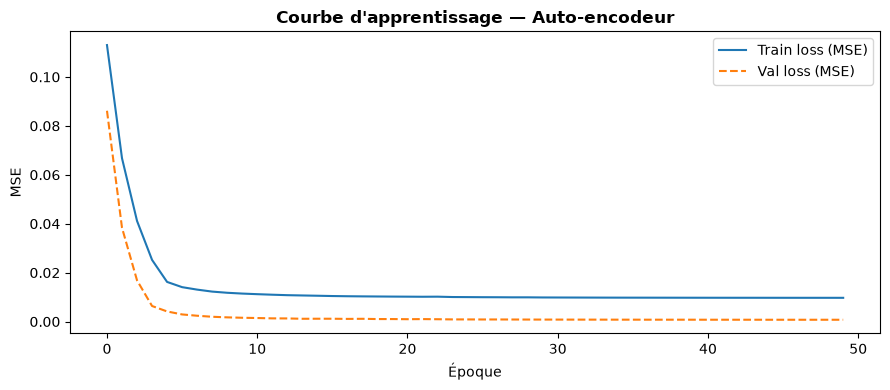

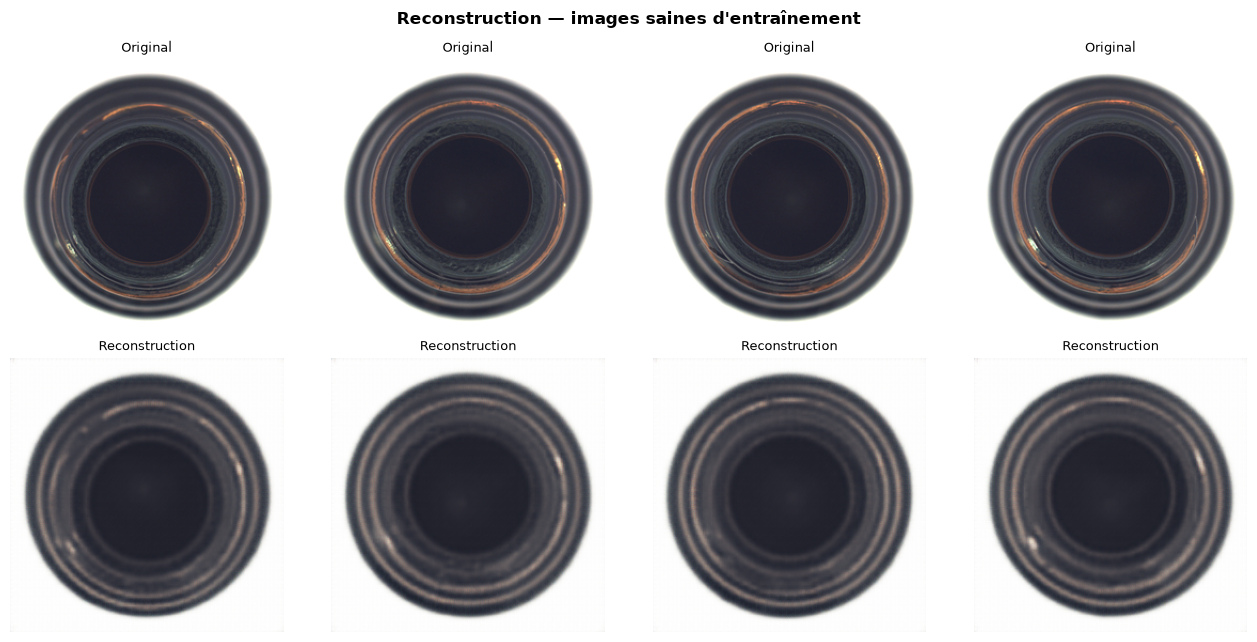

In [4]:
# ── Courbe d'apprentissage ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(history.history["loss"],     label="Train loss (MSE)")
ax.plot(history.history["val_loss"], label="Val loss (MSE)", ls="--")
ax.set_xlabel("Époque")
ax.set_ylabel("MSE")
ax.set_title("Courbe d'apprentissage — Auto-encodeur", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("figures/tp3_01_learning_curve.png", dpi=120, bbox_inches="tight")
plt.show()

# ── Exemples de reconstruction ────────────────────────────────────────────────
rng = np.random.default_rng(SEED)
sample_idx = rng.choice(len(X_train), 4, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(13, 6.5))
fig.suptitle("Reconstruction — images saines d'entraînement", fontweight="bold")
X_sample = X_train[sample_idx]
X_recon  = model.predict(X_sample, verbose=0)

for col in range(4):
    axes[0, col].imshow(X_sample[col])
    axes[0, col].set_title("Original", fontsize=9)
    axes[0, col].axis("off")
    axes[1, col].imshow(X_recon[col])
    axes[1, col].set_title("Reconstruction", fontsize=9)
    axes[1, col].axis("off")

plt.tight_layout()
plt.savefig("figures/tp3_02_reconstructions.png", dpi=120, bbox_inches="tight")
plt.show()

## §3 — Score d'anomalie & seuil

Le score par image = MSE entre l'image et sa reconstruction.

**Calibration du seuil** : on choisit le centile 99 des erreurs de validation (images saines).  
Un seuil plus bas → plus de rappel, plus de fausses alertes.  
Le bon arbitrage dépend du **coût métier** d'une panne manquée vs d'une fausse alarme.

Erreurs saines  (val) : μ=0.00074  σ=0.00009
Erreurs défauts (test): μ=0.00082  σ=0.00018

Seuil (percentile 99) : 0.00096


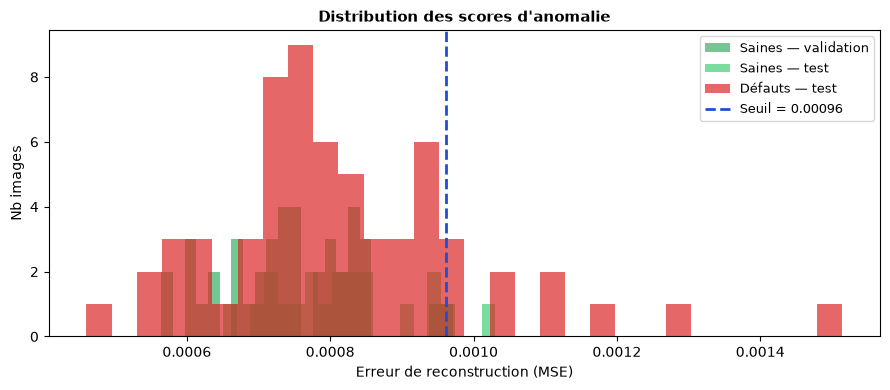

In [5]:
# ── Erreurs de reconstruction ─────────────────────────────────────────────────
errors_train  = reconstruction_errors(model, X_train)
errors_val    = reconstruction_errors(model, X_val)
errors_test   = reconstruction_errors(model, X_test)

test_arr = np.array(test_classes)
errors_test_good   = errors_test[test_arr == "good"]
errors_test_defect = errors_test[test_arr != "good"]

print(f"Erreurs saines  (val) : μ={errors_val.mean():.5f}  σ={errors_val.std():.5f}")
print(f"Erreurs défauts (test): μ={errors_test_defect.mean():.5f}  σ={errors_test_defect.std():.5f}")

# ── Calibration du seuil ─────────────────────────────────────────────────────
threshold = calibrate_threshold(errors_val, method="percentile", percentile=99)
print(f"\nSeuil (percentile 99) : {threshold:.5f}")

# ── Histogramme ──────────────────────────────────────────────────────────────
plot_score_histogram(
    errors_val, errors_test_good, errors_test_defect,
    threshold=threshold,
    save_path="figures/tp3_03_histogram.png",
)

## §4 — Heatmaps & Évaluation

La carte d'erreur par pixel localise les zones anormales. On la compare au masque de vérité terrain.

**Évaluation quantitative** : AUROC niveau image (AUC de la courbe ROC).
Un AUROC = 0.5 → classifieur aléatoire. AUROC = 1.0 → parfait.

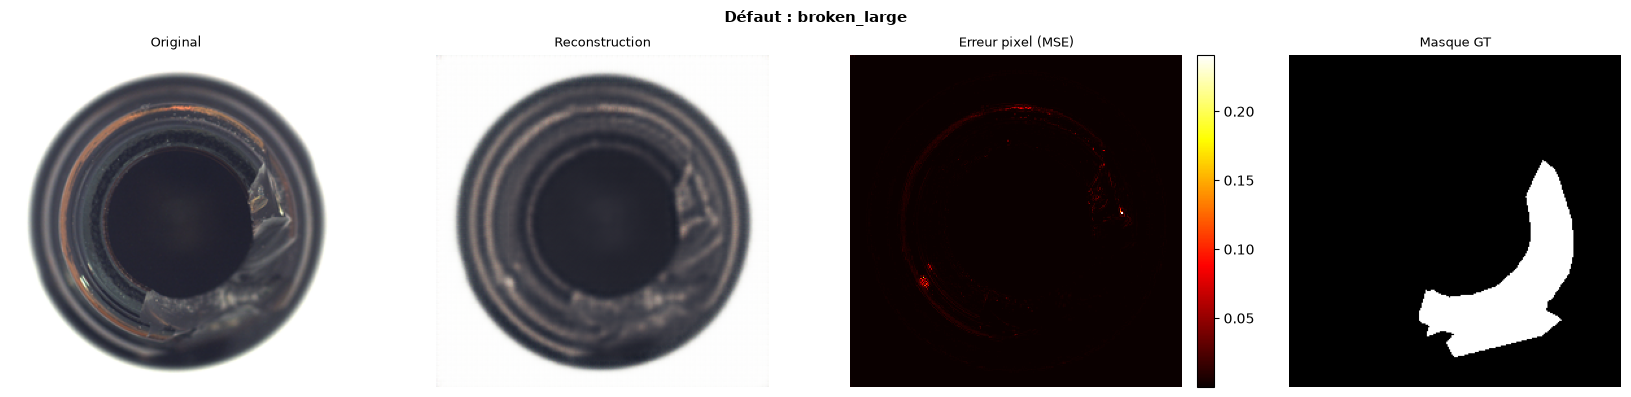

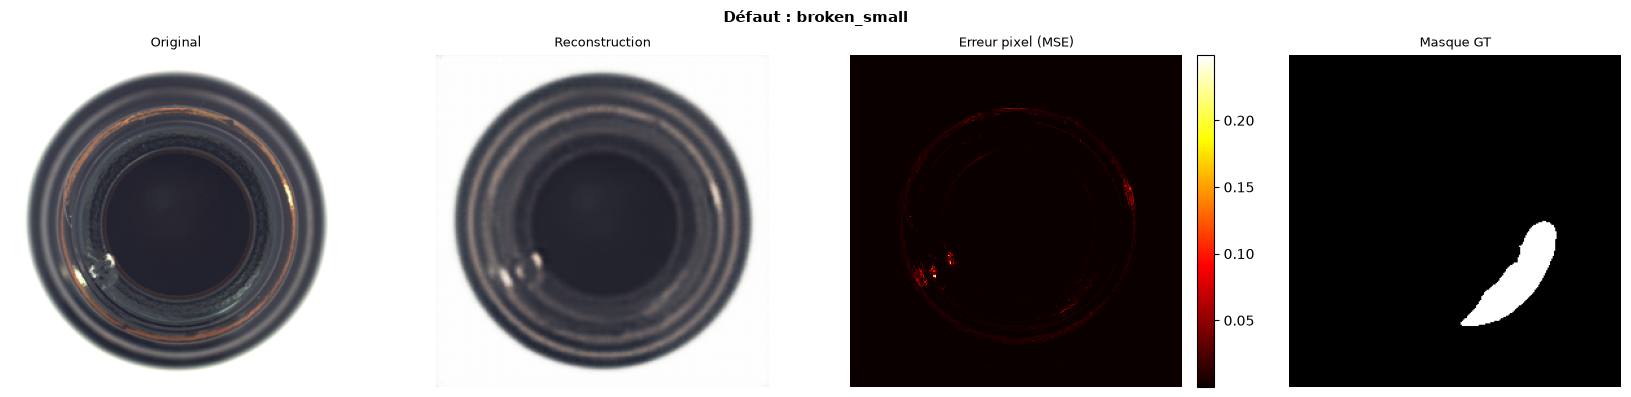

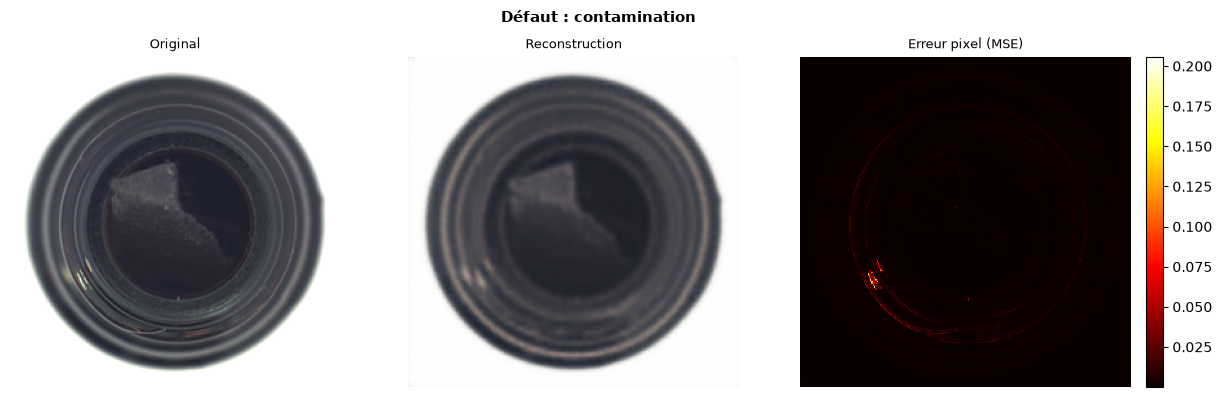

In [6]:
# ── Heatmaps pour chaque classe de défaut ────────────────────────────────────
for cls in defect_classes:
    idx_cls = np.where(test_arr == cls)[0][0]   # première image de la classe
    img     = X_test[idx_cls]
    recon, err_map = pixel_error_map(model, img)

    # Masque GT correspondant
    stem = str(idx_cls).zfill(3)
    mask_key = (cls, stem)
    mask_gt  = masks.get(mask_key, None)

    plot_heatmap(
        img, recon, err_map, mask_gt=mask_gt,
        title=f"Défaut : {cls}",
        save_path=f"figures/tp3_04_heatmap_{cls}.png",
    )

=== Métriques ===
  AUROC     : 0.465
  Rappel    : 15.87%   (défauts correctement détectés)
  Précision : 83.33%
  Spécif.   : 90.00% (saines correctement acceptées)
  TP=10  TN=18  FP=2  FN=53


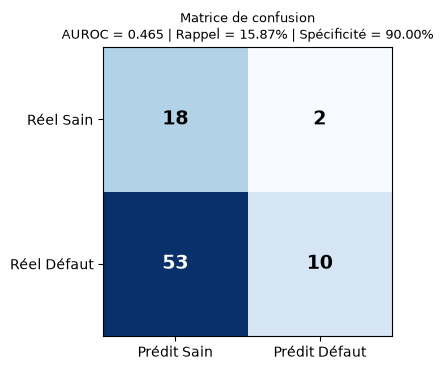

In [7]:
# ── AUROC niveau image ────────────────────────────────────────────────────────
metrics = evaluate(y_test, errors_test, threshold)

print("=== Métriques ===")
print(f"  AUROC     : {metrics['auroc']:.3f}")
print(f"  Rappel    : {metrics['recall']:.2%}   (défauts correctement détectés)")
print(f"  Précision : {metrics['precision']:.2%}")
print(f"  Spécif.   : {metrics['specificity']:.2%} (saines correctement acceptées)")
print(f"  TP={metrics['tp']}  TN={metrics['tn']}  FP={metrics['fp']}  FN={metrics['fn']}")

plot_confusion_matrix(metrics, save_path="figures/tp3_05_confusion.png")

## §5 — Analyse critique

### Ce qui fonctionne
- L'auto-encodeur apprend à reconstruire les pièces saines avec une erreur faible.
- Les défauts *grossiers* (`broken_large`) produisent une erreur plus forte → détectables.
- La heatmap localise qualitativement les zones suspectes.

### Ce qui échoue
- **Ratio de compression ≈ 1.5** : le goulot d'étranglement (32×32×128) est trop large. Le modèle peut apprendre une quasi-identité et reconstruire les défauts presque aussi bien que les pièces saines. Le signal d'anomalie est donc faible.
- Les défauts *discrets* (`broken_small`, `contamination`) produisent une erreur proche de celle des pièces saines → nombreux faux négatifs (FN élevé).
- La perte MSE est dominée par les grandes zones homogènes (fond noir) et sous-pénalise les petites altérations de texture.

### Pistes d'amélioration
- Resserrer le goulot : réduire `filters[2]` ou ajouter une couche de pooling → ratio ≥ 4.
- Passer à la perte **SSIM** ou **MSE+SSIM** (`mse_ssim_loss()`) : plus sensible aux altérations de texture.
- Comparer à **PatchCore** (lib `anomalib`) qui atteint > 98 % AUROC sur MVTec sans entraîner un modèle from scratch.